In [2]:
import sys
from pathlib import Path

# Find project root dynamically
def get_project_root() -> Path:
    try:
        path = Path(__file__).resolve()
        for parent in [path] + list(path.parents):
            if (parent / "requirements.txt").exists() or (parent / "project").exists():
                return parent
    except NameError:
        pass
    path = Path.cwd().resolve()
    for parent in [path] + list(path.parents):
        if (parent / "requirements.txt").exists() or (parent / "project").exists():
            return parent
    return path

ROOT = get_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# CIFAR-10 Dataset
transform = transforms.ToTensor() # transform images to tensors and scales value to [0,1]

trainset = datasets.CIFAR10(
    root=str(ROOT / 'data'),
    train=True,
    download=True,
    transform=transform
)

testset = datasets.CIFAR10(
    root=str(ROOT / 'data'),
    train=False,
    download=True,
    transform=transform
)

# Data Loaders
trainloader = DataLoader(
    trainset,
    batch_size=64,
    shuffle=True
)

testloader = DataLoader(
    testset,
    batch_size=64,
    shuffle=False
)

# CNN Model
class TinyCNN(nn.Module):

    def __init__(self, num_classes=10):
        super().__init__()

        # Input:
        # (B, 3, 32, 32)

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        # output = (B, 32, 32, 32) (convert 3 rgb channels to various 32 features channels)

        # input = (B, 32, 16, 16) since maxpool applied on conv1
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        # output = (B, 64, 16, 16)

        # input = (B, 64, 8, 8)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        # output = (B, 128, 4, 4)

        # halves H and W
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # after 3 pools:
        # (B,128,4,4)
        self.fc1 = nn.Linear(128 * 4 * 4, 256)

        self.fc2 = nn.Linear(256, num_classes)

        self.dropout = nn.Dropout(0.3)

    def forward(self, x):

        # (B,3,32,32)
        x = self.pool(F.relu(self.conv1(x)))

        # (B,32,16,16)
        x = self.pool(F.relu(self.conv2(x)))

        # (B,64,8,8)
        x = self.pool(F.relu(self.conv3(x)))

        # (B,128,4,4)

        # flatten everything except batch dimension
        x = x.flatten(1)

        # (B,2048)
        x = self.dropout(F.relu(self.fc1(x)))

        # (B,256)

        # output logits
        x = self.fc2(x)

        # (B,10)
        return x


# Model
model = TinyCNN().to(device)

# Loss Function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

train_accs = []
val_accs = []

# Training Loop
epochs = 10

for epoch in range(epochs):

    model.train()

    train_correct = 0
    train_total = 0
    train_loss = 0.0

    for images, labels in trainloader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels) # measures loss

        loss.backward() # computes gradients

        optimizer.step() # inproves weight

        train_loss += loss.item()

        predictions = outputs.argmax(dim=1)

        train_correct += (predictions == labels).sum().item()

        train_total += labels.size(0)

    train_accuracy = (
        100 * train_correct / train_total
    )

    train_accs.append(train_accuracy)
    val_accs.append(val_accuracy)


    model.eval()

    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in testloader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            predictions = outputs.argmax(dim=1)

            val_correct += (
                predictions == labels
            ).sum().item()

            val_total += labels.size(0)

    val_accuracy = (
        100 * val_correct / val_total
    )

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train Acc: {train_accuracy:.2f}% | "
        f"Val Acc: {val_accuracy:.2f}%"
    )


Epoch 1/10 | Train Acc: 41.12% | Val Acc: 53.77%
Epoch 2/10 | Train Acc: 57.03% | Val Acc: 62.03%
Epoch 3/10 | Train Acc: 63.44% | Val Acc: 66.32%
Epoch 4/10 | Train Acc: 67.53% | Val Acc: 68.86%
Epoch 5/10 | Train Acc: 70.68% | Val Acc: 70.07%
Epoch 6/10 | Train Acc: 73.47% | Val Acc: 71.84%
Epoch 7/10 | Train Acc: 75.36% | Val Acc: 71.81%
Epoch 8/10 | Train Acc: 77.26% | Val Acc: 73.06%
Epoch 9/10 | Train Acc: 78.90% | Val Acc: 73.47%
Epoch 10/10 | Train Acc: 80.30% | Val Acc: 73.90%


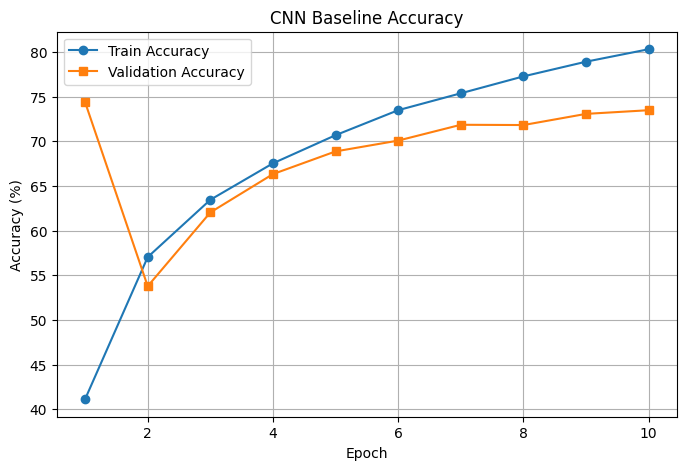

In [3]:
import matplotlib.pyplot as plt

epochs_range = range(1, epochs + 1)

plt.figure(figsize=(8,5))

plt.plot(
    epochs_range,
    train_accs,
    marker='o',
    label='Train Accuracy'
)

plt.plot(
    epochs_range,
    val_accs,
    marker='s',
    label='Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('CNN Baseline Accuracy')
plt.legend()
plt.grid(True)

plt.savefig('cnn_baseline_curves.png')
plt.show()